In [4]:
from dotenv import load_dotenv
load_dotenv()

True

In [2]:
from pydantic import BaseModel 
from langchain_groq import ChatGroq
from langgraph.graph import StateGraph, START, END 
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import InMemorySaver
from typing import Annotated

In [3]:
class ChatState(BaseModel) : 
    messages : Annotated[list, add_messages]

In [4]:
llm = ChatGroq(
    model = "openai/gpt-oss-120b"
)

In [5]:
def chatBotNode(state : ChatState) -> ChatState : 
    res = llm.invoke(state.messages)
    state.messages = [res]
    return state

In [6]:
memory = InMemorySaver()

In [7]:
graph = StateGraph(ChatState)
graph.add_node("chatBot", chatBotNode)

graph.add_edge(START, "chatBot")
graph.add_edge("chatBot", END)

graph = graph.compile(checkpointer=memory)

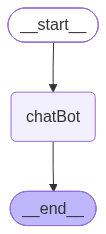

In [8]:
from IPython.display import Image
Image(graph.get_graph().draw_mermaid_png())

In [10]:
config = {"configurable" : {"thread_id" : "my-bot"}}
res = graph.invoke({"messages" : [{"role" : "user", "content" : "Hello, how are you? I am Prince Raj"}]}, config)

In [11]:
res

{'messages': [HumanMessage(content='Hello, how are you? I am Prince Raj', additional_kwargs={}, response_metadata={}, id='4eef0057-0783-40b5-ae0c-c5068dbb7d9a'),
  AIMessage(content='Hello, Prince Raj! I’m doing great, thank you for asking. How can I assist you today?', additional_kwargs={'reasoning_content': 'The user says "Hello, how are you? I am Prince Raj". The user is greeting. The assistant should respond politely, possibly asking how can help. No disallowed content. So respond friendly.'}, response_metadata={'token_usage': {'completion_tokens': 73, 'prompt_tokens': 81, 'total_tokens': 154, 'completion_time': 0.155563378, 'completion_tokens_details': {'reasoning_tokens': 42}, 'prompt_time': 0.01310544, 'prompt_tokens_details': None, 'queue_time': 0.316703816, 'total_time': 0.168668818}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_f73454f048', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a0f36a

In [12]:
res["messages"][-1].content

'Hello, Prince Raj! I’m doing great, thank you for asking. How can I assist you today?'

In [13]:
config = {"configurable" : {"thread_id" : "my-bot"}}
res = graph.invoke({"messages" : [{"role" : "user", "content" : "What is my name?"}]}, config)

In [15]:
print(res["messages"][-1].content)

Your name is Prince Raj.
